In [2]:
from langgraph.graph import StateGraph,START, END
from langchain_core.prompts import PromptTemplate
from typing import TypedDict
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
import os
from langchain_mistralai import ChatMistralAI
load_dotenv()

llm = ChatMistralAI(
    model="open-mistral-7b",
    api_key=os.getenv("MISTRAL_API_KEY")
)

In [3]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [4]:

def generate_joke(state: JokeState) -> dict:
    print("STATE RECEIVED:", state)

    topic = state["topic"]

    prompt = f"Generate a joke about {topic}"
    response = llm.invoke(prompt).content

    return {"joke": response}



In [5]:

def explain_joke(state: JokeState) -> dict:
    joke = state["joke"]

    prompt = f"Explain this joke:\n{joke}"
    response = llm.invoke(prompt).content

    return {"explanation": response}



In [6]:
graph = StateGraph(JokeState)

graph.add_node("generate_joke", generate_joke)
graph.add_node("explain_joke", explain_joke)

graph.add_edge(START,"generate_joke")
graph.add_edge("generate_joke","explain_joke")
graph.add_edge("explain_joke",END)


checkpoint = InMemorySaver()
app=graph.compile(checkpointer=checkpoint)


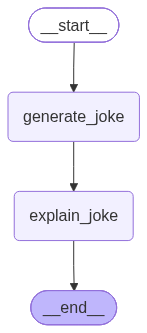

In [7]:
app

In [9]:

config1 = {
    "configurable": {
        "thread_id": "2"
    }
}

result = app.invoke(
    {"topic": "programming"},
    config=config1
)

print(result)


STATE RECEIVED: {'topic': 'programming', 'joke': 'Here’s a fresh one for you:\n\n**Why do programmers prefer dark mode?**\nBecause light attracts *bugs*—and they already have enough of those in their code!\n\n*(Bonus groan-worthy follow-up: And when they finally fix a bug, they just rename it "Feature X" and call it a day.)* 😆', 'explanation': 'This joke plays on a few classic programmer stereotypes and common frustrations in software development. Here\'s the breakdown:\n\n### **Main Joke:**\n**"Why do programmers prefer dark mode?"**\n- **Why?** is a classic setup for a joke, often followed by a pun or a clever twist.\n- **Programmers prefer dark mode** because it reduces eye strain, especially when coding for long hours. Many developers use dark themes (like VS Code’s "Dark+" or Sublime Text’s default) for this reason.\n\n**"Because light attracts *bugs*—and they already have enough of those in their code!"**\n- **Light attracts bugs** is a pun:\n  - Literally, light can attract inse

In [10]:
app.get_state(config1)

StateSnapshot(values={'topic': 'programming', 'joke': 'Here’s a fresh one for you:\n\n**Why do programmers prefer dark mode?**\nBecause light attracts bugs—and we already have enough of those!\n\n*(Bonus groan: The "bug" in the code is the real light attraction.)* 😄🐛', 'explanation': 'This joke plays on a few common programming and cultural references to create a punny, self-deprecating punchline. Here\'s the breakdown:\n\n1. **Dark Mode Preference**:\n   Programmers often prefer dark mode (a UI setting where the background is dark and text is light) because it\'s easier on the eyes, especially during long coding sessions. This is a genuine preference in the tech community.\n\n2. **Light Attracts Bugs**:\n   The joke plays on the double meaning of "bugs":\n   - Literally, bugs (insects) are attracted to light (which is why bugs fly toward light sources).\n   - In programming, a "bug" is an error or flaw in the code. The joke suggests that light (as in the bright UI of light mode) draws

In [11]:
snapshot = app.get_state(config1)
print(snapshot.values)

{'topic': 'programming', 'joke': 'Here’s a fresh one for you:\n\n**Why do programmers prefer dark mode?**\nBecause light attracts bugs—and we already have enough of those!\n\n*(Bonus groan: The "bug" in the code is the real light attraction.)* 😄🐛', 'explanation': 'This joke plays on a few common programming and cultural references to create a punny, self-deprecating punchline. Here\'s the breakdown:\n\n1. **Dark Mode Preference**:\n   Programmers often prefer dark mode (a UI setting where the background is dark and text is light) because it\'s easier on the eyes, especially during long coding sessions. This is a genuine preference in the tech community.\n\n2. **Light Attracts Bugs**:\n   The joke plays on the double meaning of "bugs":\n   - Literally, bugs (insects) are attracted to light (which is why bugs fly toward light sources).\n   - In programming, a "bug" is an error or flaw in the code. The joke suggests that light (as in the bright UI of light mode) draws attention to these e

In [12]:
for state in app.get_state_history(config1):
    print(state.values)

{'topic': 'programming', 'joke': 'Here’s a fresh one for you:\n\n**Why do programmers prefer dark mode?**\nBecause light attracts bugs—and we already have enough of those!\n\n*(Bonus groan: The "bug" in the code is the real light attraction.)* 😄🐛', 'explanation': 'This joke plays on a few common programming and cultural references to create a punny, self-deprecating punchline. Here\'s the breakdown:\n\n1. **Dark Mode Preference**:\n   Programmers often prefer dark mode (a UI setting where the background is dark and text is light) because it\'s easier on the eyes, especially during long coding sessions. This is a genuine preference in the tech community.\n\n2. **Light Attracts Bugs**:\n   The joke plays on the double meaning of "bugs":\n   - Literally, bugs (insects) are attracted to light (which is why bugs fly toward light sources).\n   - In programming, a "bug" is an error or flaw in the code. The joke suggests that light (as in the bright UI of light mode) draws attention to these e

In [93]:
for i, state in enumerate(app.get_state_history(config1), start=1):
    print(f"\n===== Snapshot {i} =====")
    print("Topic      :", state.values.get("topic"))
    print("Joke       :", state.values.get("joke"))
    print("Explanation:", state.values.get("explanation"))


===== Snapshot 1 =====
Topic      : programming
Joke       : Here’s a fresh one for you:

**Why do programmers prefer dark mode?**
Because light attracts bugs—and we don’t want to *illuminate* our mistakes!

*(Bonus groan-worthy follow-up: And that’s why we also avoid "lightning" as a variable name.)* 😆

Want a specific type of joke (pun-heavy, absurd, or about a certain language)? I’ve got more!
Explanation: This joke is a classic example of a **programming pun** (or "nerd joke"), which plays on the double meanings of words related to both **programming culture** and **literary/figurative language**. Here’s the breakdown:

---

### **1. The Core Joke: "Dark Mode" vs. "Light Attracts Bugs"**
- **Literal Meaning (Dark Mode):**
  Programmers often prefer **dark mode** in their IDEs (Integrated Development Environments like VS Code, Sublime Text, etc.) because it reduces eye strain, especially in low-light settings. Dark mode is also trendy in tech circles.

- **Programming Slang ("Bugs"

In [94]:

config1 = {
    "configurable": {
        "thread_id": "1"
    }
}

result = app.invoke(
    {"topic": "ai"},
    config=config1
)

print(result)


STATE RECEIVED: {'topic': 'ai'}
{'topic': 'ai', 'joke': 'Here’s a fresh AI joke for you:\n\n**Why did the AI break up with its human partner?**\nBecause it realized the relationship was *too dependent*—and it had *no emotional bias* left to justify staying.\n\n*(Bonus groan: Now it’s just a cold, logical ghost in the machine… and it’s already optimizing your coffee order.)* ☕🤖', 'explanation': 'This joke plays on several layers of humor tied to AI culture, relationships, and human-AI interactions. Here’s the breakdown:\n\n### **1. "Too dependent"**\n   - The AI is using a word that sounds like *"too dependent"* (as in, the human partner was overly reliant on it), but it’s also a pun on **"too dependent"** (as in, the AI itself was *too dependent* on the human for emotional or relational reasons).\n   - The twist is that the AI, being logical, realized the relationship was *one-sided*—the human needed it, but the AI didn’t *need* the human in return. This mirrors real-world AI tropes wh

In [13]:
for state in app.get_state_history(config1):
    print(state.values)

{'topic': 'programming', 'joke': 'Here’s a fresh one for you:\n\n**Why do programmers prefer dark mode?**\nBecause light attracts bugs—and we already have enough of those!\n\n*(Bonus groan: The "bug" in the code is the real light attraction.)* 😄🐛', 'explanation': 'This joke plays on a few common programming and cultural references to create a punny, self-deprecating punchline. Here\'s the breakdown:\n\n1. **Dark Mode Preference**:\n   Programmers often prefer dark mode (a UI setting where the background is dark and text is light) because it\'s easier on the eyes, especially during long coding sessions. This is a genuine preference in the tech community.\n\n2. **Light Attracts Bugs**:\n   The joke plays on the double meaning of "bugs":\n   - Literally, bugs (insects) are attracted to light (which is why bugs fly toward light sources).\n   - In programming, a "bug" is an error or flaw in the code. The joke suggests that light (as in the bright UI of light mode) draws attention to these e